# BraTS-Africa Brain Tumor Segmentation

This notebook reproduces the data preparation and preprocessing workflow
described in the BraTS-Africa tutorial. The goal is to understand each stage
of preparing 3D MRI data for brain tumor segmentation using a U-Net-based
deep learning approach.

## Phase 1: Data Collection and Preprocessing

In this phase, the BraTS-Africa dataset is downloaded, loaded, inspected, normalized, visualized, and prepared for model training.

The dataset contains 3D brain MRI scans acquired using four MRI modalities:

- T1n - T1-weighted native
- T1c - T1-weighted contrast-enhanced
- T2f - T2-weighted fluid-sensitive
- T2w - T2-weighted

Each patient also has a corresponding segmentation mask containing labels for different tumor regions.

The main goal of this phase is to transform the raw NIfTI medical images into standardized NumPy arrays that can later be used as inputs and targets for the segmentation model.

### 1. Loading the MRI Data

Nibabel is used to load the NIfTI files and convert them into NumPy arrays. The four MRI modalities and their corresponding segmentation mask are loaded for a sample patient.

In [1]:
import numpy as np
import nibabel as nib

#Define the path to your dataset
TRAIN_DATASET_PATH = 'BraTS-Africa/95_Glioma'

#Load sample images and visualize
image_t1n = nib.load(TRAIN_DATASET_PATH + '/BraTS-SSA-00008-000/BraTS-SSA-00008-000-t1n.nii.gz').get_fdata()
image_t1c = nib.load(TRAIN_DATASET_PATH + '/BraTS-SSA-00008-000/BraTS-SSA-00008-000-t1c.nii.gz').get_fdata()
image_t2f = nib.load(TRAIN_DATASET_PATH + '/BraTS-SSA-00008-000/BraTS-SSA-00008-000-t2f.nii.gz').get_fdata()
image_t2w = nib.load(TRAIN_DATASET_PATH + '/BraTS-SSA-00008-000/BraTS-SSA-00008-000-t2w.nii.gz').get_fdata()
mask = nib.load(TRAIN_DATASET_PATH + '/BraTS-SSA-00008-000/BraTS-SSA-00008-000-seg.nii.gz').get_fdata()

### 2. Intensity Scaling

MRI intensity values can vary between scans. Min-Max scaling standardizes each modality to a range of 0–1.

The 3D volume is temporarily reshaped to 2D because `MinMaxScaler` operates on 2D data, then reshaped back to its original 3D structure.

In [2]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
 
image_t1n = scaler.fit_transform(image_t1n.reshape(-1,image_t1n.shape[-1])).reshape(image_t1n.shape)
image_t1c = scaler.fit_transform(image_t1c.reshape(-1,image_t1c.shape[-1])).reshape(image_t1c.shape)
image_t2f=scaler.fit_transform(image_t2f.reshape(-1,image_t2f.shape[-1])).reshape(image_t2f.shape)
image_t2w = scaler.fit_transform(image_t2w.reshape(-1,image_t2w.shape[-1])).reshape(image_t2w.shape)


### 3. Processing the Segmentation Mask

The segmentation mask contains integer labels representing different tumor regions. The labels are converted to `uint8`, and label 4 is reassigned to 3 so that the final classes are 0–3.

In [3]:
mask = mask.astype(np.uint8)
mask[mask== 4] = 3 # Reassign mask values 4 to 3

### 4. Visualizing the MRI and Mask

A random slice is displayed from each MRI modality alongside its segmentation mask. This provides a visual check that the images were loaded and processed correctly.

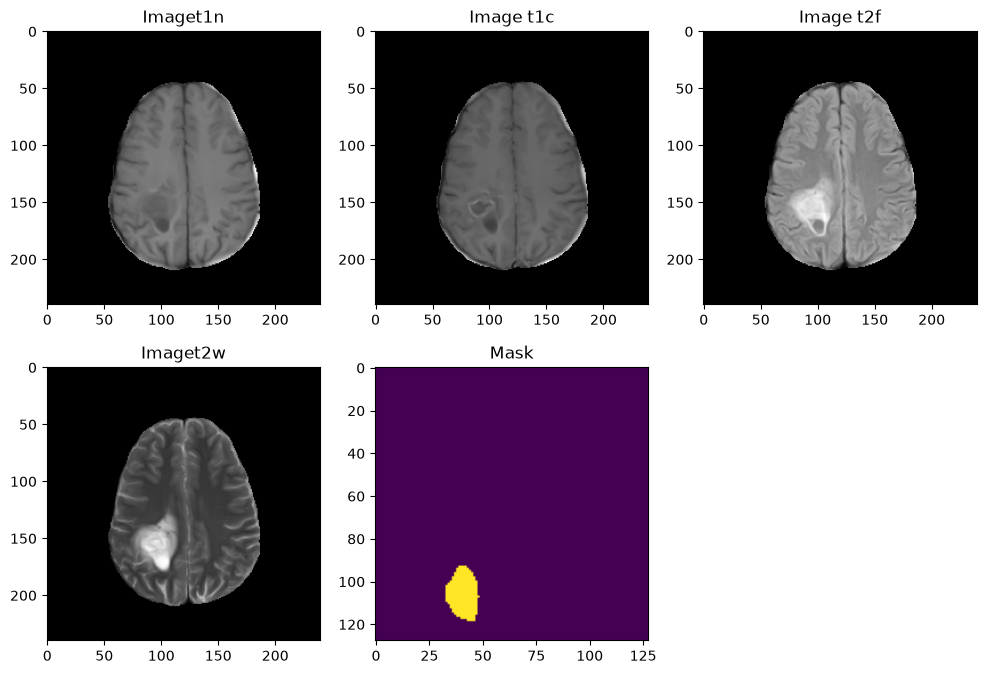

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

n_slice = n_slice = random.randint(0, mask.shape[2] - 1) #this picks random slice for viewing


plt.figure(figsize=(12,8))

plt.subplot(231)
plt.imshow(np.rot90(image_t1n[:,:, n_slice]), cmap='gray')
plt.title('Imaget1n')

plt.subplot(232)
plt.imshow(np.rot90(image_t1c[:,:, n_slice]), cmap='gray')
plt.title('Image t1c')

plt.subplot(233)
plt.imshow(np.rot90(image_t2f[:,:, n_slice]), cmap='gray')
plt.title('Image t2f')

plt.subplot(234)
plt.imshow(np.rot90(image_t2w[:,:, n_slice]), cmap='gray')
plt.title('Imaget2w')

plt.subplot(235)
plt.imshow(np.rot90(mask[:,:, n_slice]))
plt.title('Mask')

plt.show()

### 5. Combining Modalities and Cropping

The four MRI modalities are stacked as four channels, allowing the model to learn from their complementary information.

The volume is then cropped from 256³ to 128³ to reduce the computational and memory requirements.

In [5]:
combined_x = np.stack([image_t1n, image_t1c, image_t2f, image_t2w], axis=3)

In [6]:
combined_x = combined_x[56:184, 56:184, 13:141] #Crop to 128x128x128
mask = mask[56:184, 56:184, 13:141]

### 6. Processing the Full Dataset

The preprocessing steps are applied to all patient folders. Cases with insufficient tumor information are excluded, while the remaining images and masks are converted to NumPy arrays and saved for the next stage of the pipeline.

In [7]:
import glob
import os
import nibabel as nib
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical

# Initialize scaler
scaler = MinMaxScaler()

# Create output folders
os.makedirs('glioma/images', exist_ok=True)
os.makedirs('glioma/masks', exist_ok=True)

TRAIN_DATASET_PATH = "BraTS-Africa/95_Glioma"

# List all patient folders
patient_folders = glob.glob(os.path.join(TRAIN_DATASET_PATH, '*'))

# Loop over each patient folder
for img, folder in enumerate(patient_folders):
    # Construct paths
    t1n_path = glob.glob(os.path.join(folder, '*t1n.nii.gz'))
    t1c_path = glob.glob(os.path.join(folder, '*t1c.nii.gz'))
    t2f_path = glob.glob(os.path.join(folder, '*t2f.nii.gz'))
    t2w_path = glob.glob(os.path.join(folder, '*t2w.nii.gz'))
    mask_path = glob.glob(os.path.join(folder, '*seg.nii.gz'))

    # Check if all required files are present
    if not (t1n_path and t1c_path and t2f_path and t2w_path and mask_path):
        print(f"[SKIP] Missing modalities or mask in folder: {folder}")
        continue

    print("Now preparing image and masks number:", img)

    # Load and scale modalities
    def load_and_scale(img_path):
        img_data = nib.load(img_path[0]).get_fdata()
        img_data = scaler.fit_transform(img_data.reshape(-1, img_data.shape[-1])).reshape(img_data.shape)
        return img_data

    try:
        temp_image_t1n = load_and_scale(t1n_path)
        temp_image_t1c = load_and_scale(t1c_path)
        temp_image_t2f = load_and_scale(t2f_path)
        temp_image_t2w = load_and_scale(t2w_path)

        temp_mask = nib.load(mask_path[0]).get_fdata()
        temp_mask = temp_mask.astype(np.uint8)
        temp_mask[temp_mask == 4] = 3 # Reassign mask value 4 to 3

        # Combine modalities
        temp_combined_images = np.stack([temp_image_t1n, temp_image_t1c, temp_image_t2f, temp_image_t2w], axis=3)

        # Crop to desired shape
        temp_combined_images = temp_combined_images[56:184, 56:184, 13:141]
        temp_mask = temp_mask[56:184, 56:184, 13:141]

        val, counts = np.unique(temp_mask, return_counts=True)

        if len(counts) > 1 and (1 - (counts[0] / counts.sum())) > 0.01:
            print("Save Me")
            temp_mask = to_categorical(temp_mask, num_classes=4)
            np.save(f'glioma/images/image_{img}.npy', temp_combined_images)
            np.save(f'glioma/masks/mask_{img}.npy', temp_mask)
        else:
            print("I am not a good addition to the model")
    except Exception as e:
        print(f"[ERROR] Failed to process {folder}: {e}")
        continue

Now preparing image and masks number: 0
Save Me
Now preparing image and masks number: 1
Save Me
Now preparing image and masks number: 2
Save Me
Now preparing image and masks number: 3
Save Me
Now preparing image and masks number: 4
Save Me
Now preparing image and masks number: 5
Save Me
Now preparing image and masks number: 6
Save Me
Now preparing image and masks number: 7
Save Me
Now preparing image and masks number: 8
Save Me
Now preparing image and masks number: 9
Save Me
Now preparing image and masks number: 10
Save Me
Now preparing image and masks number: 11
Save Me
Now preparing image and masks number: 12
Save Me
Now preparing image and masks number: 13
Save Me
Now preparing image and masks number: 14
Save Me
Now preparing image and masks number: 15
I am not a good addition to the model
Now preparing image and masks number: 16
Save Me
Now preparing image and masks number: 17
Save Me
Now preparing image and masks number: 18
Save Me
Now preparing image and masks number: 19
Save Me


In [8]:
import splitfolders
import os

os.makedirs('glioma split data', exist_ok=True)

input_folder = 'glioma/'
output_folder = 'glioma split data/'
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .15, .10), group_prefix=None)

### Phase 1 Summary

The raw NIfTI scans have been converted into normalized, cropped, multi-channel NumPy arrays with corresponding one-hot encoded segmentation masks. These processed data are now ready for dataset splitting and model preparation.